<a href="https://colab.research.google.com/github/sarwathasan72-svg/Masai_IIT_AIML/blob/main/Module4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Simple Liner Regression

from sklearn.linear_model import LinearRegression
from io import StringIO
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, mean_squared_error, r2_score
import numpy as np



print("hi")


csv_data = """experience,salary
1,28000
2,36000
3,44000
4,52000
5,60000
6,68000
7,76000
8,84000
9,92000
10,100000"""

csv_data = pd.read_csv(StringIO(csv_data))

csv_data

X = csv_data[["experience"]]

Y = csv_data["salary"]

X_train, X_test, Y_train, Y_test = train_test_split (
    X,
    Y,
    test_size = 0.2,
    random_state = 42
)

linear_reg = LinearRegression()

linear_reg.fit(X_train, Y_train)

model_prediction = linear_reg.predict(X_test)

model_prediction

mae = mean_absolute_error(Y_test, model_prediction)

mse = mean_squared_error(Y_test, model_prediction)

rmse = np.sqrt(mse)

r2 =  r2_score(Y_test, model_prediction)


print("\n Actual value : ", Y_test)

print("\n Predicted value : ", model_prediction)

print("\n MAE: ", mae)

print("\n MSE: ", mse)

print("\n RMSE: ", rmse)

print("\n R2: ", r2)

print("\n Cofficient : " , linear_reg.coef_[0])


print("\n Intercept : " , linear_reg.intercept_)

# Predict and report the estimated salary for a new candidate with 12 years of experience.

# new_candidate_sal = linear_reg.predict([[12]])

# Alternate way

new_candidate_df = pd.DataFrame({
    "experience": [12]
})

new_candidate_sal = linear_reg.predict(new_candidate_df)

print("\n New Candidate Salary : ", new_candidate_sal)



hi

 Actual value :  8    92000
1    36000
Name: salary, dtype: int64

 Predicted value :  [92000. 36000.]

 MAE:  0.0

 MSE:  0.0

 RMSE:  0.0

 R2:  1.0

 Cofficient :  8000.0

 Intercept :  20000.0

 New Candidate Salary :  [116000.]



MULT LINEAR REGRESSION

A data science team at a real-estate analytics startup wants a small, reusable evaluation utility for their apartment price prediction models. A senior data analyst has asked a teammate to write a Python function that takes a set of actual and predicted apartment prices, computes the residuals, MSE, RMSE, and R² manually using NumPy, and then cross-checks the manually computed MSE and R² against scikit-learn's mean_squared_error and r2_score functions — printing a confirmation message whenever the manual and scikit-learn values agree within floating-point tolerance. size_sqft = [600, 800, 1000, 1200, 1500] actual_price = [40, 55, 58, 65, 90] predicted_price = [40, 50, 60, 70, 85] import numpy as np from sklearn.metrics import mean_squared_error, r2_score

1. Use numpy for the manual calculations and sklearn.metrics.mean_squared_error / sklearn.metrics.r2_score for the scikit-learn cross-check.
2. The function must accept two equal-length sequences (actual values and predicted values) and work correctly for the five-row sample provided below.
3. Round RMSE and R² to two and four decimal places respectively, matching the rounding convention used for reporting these metrics.
4. Use np.isclose() to compare the manual and scikit-learn results, and only print a confirmation message when they match.
5. Do not hardcode the sample values inside the function — the function must accept the actual and predicted arrays as parameters so it can be reused on other datasets.

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error


size_sqft = [600, 800, 1000, 1200, 1500]
actual_price = [40, 55, 58, 65, 90]
predicted_price = [40, 50, 60, 70, 85]

def evaluate_regression(actual_price,predicted_price):


    actual_price = np.array(actual_price)

    predicted_price = np.array(predicted_price)

    residual = actual_price - predicted_price
    np_MSE = np.mean(residual**2)

    np_RMSE = np.sqrt(np_MSE)

    # np_r2 = 1 - ss_resi/ss_tot

    ss_resi = np.sum(residual**2)
    ss_tot = np.sum((actual_price - np.mean(actual_price))**2)

    np_r2 = 1-ss_resi/ss_tot

    print(np_r2)

    sk_MSE = mean_squared_error(actual_price,predicted_price)

    if np.isclose(sk_MSE,np_MSE):
      print("MSE Matched: ", sk_MSE)

    sk_R2 = r2_score(actual_price,predicted_price)

    if np.isclose(sk_R2, np_r2):
      print("r2 match:", np_r2)

    return {
        "np_r2": np_r2
    }



result = evaluate_regression(actual_price, predicted_price)

# print(result)




0.9410975246048315
MSE Matched:  15.8
r2 match: 0.9410975246048315


In [ ]:
# The price of the house can dependent upon multiple features:

# 1. sqft area
# 2. location
# 3. bhk
# 4. age
# 5. floor
# y = w0 + w1*x1 + w2*x2 + ...

# w0 --> intercept
# every feature has its own weight(coefficient)


import pandas as pd

from sklearn.linear_model import LinearRegression




data = {

"HouseSize":[1000,1200,1500,1800,2000,2200,2500,2700],

"Bedrooms":[2,2,3,3,4,4,5,5],

"Age":[20,18,15,10,8,6,5,3],

"Price":[40,48,60,72,80,88,100,110]

}

df = pd.DataFrame(data)

df

x = df.drop("Price", axis = 1)
x
y = df["Price"]

model = LinearRegression()

model.fit(x,y)

model.predict([[5000, 6, 45]])



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([231.01152738])

In [ ]:



import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_regression(actual, predicted):
    # Step 1: Convert inputs to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)

    # Compute residuals and squared residuals
    residuals = actual - predicted
    squared_residuals = residuals ** 2

    # Step 2: Compute MSE manually and via sklearn
    mse_manual = np.mean(squared_residuals)
    mse_sklearn = mean_squared_error(actual, predicted)

    if np.isclose(mse_manual, mse_sklearn):
        print("✅ Manual MSE matches scikit-learn MSE")

    # Step 3: Compute RMSE
    rmse_manual = np.sqrt(mse_manual)

    # Step 4: Compute R² manually
    ss_residual = np.sum(squared_residuals)
    ss_total = np.sum((actual - np.mean(actual)) ** 2)

    r2_manual = 1 - (ss_residual / ss_total)
    r2_sklearn = r2_score(actual, predicted)

    if np.isclose(r2_manual, r2_sklearn):
        print("✅ Manual R² matches scikit-learn R²")

    # Step 5: Return all metrics
    return {
        "Residuals": residuals,
        "Squared Residuals": squared_residuals,
        "MSE (Manual)": mse_manual,
        "MSE (Sklearn)": mse_sklearn,
        "RMSE": rmse_manual,
        "R² (Manual)": r2_manual,
        "R² (Sklearn)": r2_sklearn
    }


if __name__ == "__main__":
    actual_price = [40, 55, 58, 65, 90]
    predicted_price = [40, 50, 60, 70, 85]

    results = evaluate_regression(actual_price, predicted_price)

    print("\nEvaluation Results:")
    for key, value in results.items():
        print(f"{key}: {value}")

✅ Manual MSE matches scikit-learn MSE
✅ Manual R² matches scikit-learn R²

Evaluation Results:
Residuals: [ 0  5 -2 -5  5]
Squared Residuals: [ 0 25  4 25 25]
MSE (Manual): 15.8
MSE (Sklearn): 15.8
RMSE: 3.9749213828703582
R² (Manual): 0.9410975246048315
R² (Sklearn): 0.9410975246048315


In [ ]:


#                  Supervised Learning
#                         │
#         ┌───────────────┴───────────────┐
#         │                               │
#    Regression                     Classification
#         │                               │
#   ┌─────┴─────┐                   ┌─────┴──────────────┐
#   │           │                   │                    │
# Simple      Multiple         Logistic Regression   Decision Tree
# Linear      Linear           KNN                  Random Forest
# Regression  Regression       SVM                  Neural Network


# Classification has many algorithms

# Classification
# │
# ├── Logistic Regression
# ├── Decision Tree
# ├── Random Forest
# ├── KNN
# ├── SVM
# └── Neural Network


# Student Data
#       │
#       ▼
# Is the output a category?
#       │
#       ▼
# Classification Problem
#       │
# Choose an algorithm
#       │
#  ┌───────────────┐
#  │ Logistic Regression │
#  └───────────────┘
#       │
#       ▼
# Prediction
# Pass / Fail

------------------------------------------------

# Step 3: Logistic Regression

# Now suppose the problem changes.

# Instead of predicting salary, you want to predict: Will the employee leave the company?

# Possible outputs

# Yes
# No

# or

# 1
# 0

# This is Classification.

# Logistic Regression starts with the same kind of linear equation:

# z = b0 + b1x1 + b2x2 + ...

# Then it adds one extra step.

# Instead of using z directly, it passes z through the Sigmoid Function.

# Linear Equation
#        │
#        ▼
# z = b0 + b1x1 + b2x2
#        │
#        ▼
# Sigmoid Function
#        │
#        ▼
# Probability (0 to 1)
#        │
#        ▼
# Class (0 or 1)

In [ ]:

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import numpy as np

# Your data
X = np.array([[1], [2], [3]])  # house sizes
y = np.array([100, 150, 200])  # actual prices

# Train the model
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Calculate MSE
mse = mean_squared_error(y, y_pred)
print(f"MSE: {mse}")

# Calculate R²
r2 = r2_score(y, y_pred)
print(f"R²: {r2}")

MSE: 3.365806528942984e-28
R²: 1.0


Classification Evaluation: The Confusion Matrix - Subjective
tp: 5 tn: 3 fp : 2 fn : 2 Accuracy :  0.6666666666666666
None

 Confusion Matrix : [[3 2]
 [2 5]]

 : tn_sk 3 fp_sk: 2 tp_sk : 5


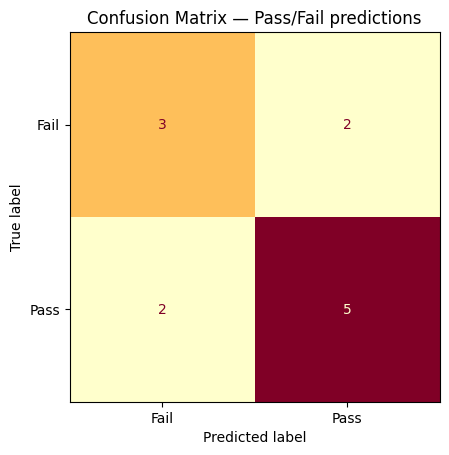

In [ ]:
# A backend engineer at an ed-tech platform has been handed the actual and predicted pass/fail outcomes for 12 learners from a newly deployed classification model. Before the model can be signed off, the engineer must evaluate it the same way covered for the pass/fail confusion matrix: compute TP, TN, FP, and FN by hand (without directly calling scikit-learn's confusion_matrix for the core computation), derive accuracy from those four counts, cross-check the manual counts against scikit-learn's confusion_matrix, and isolate exactly which learners were misclassified.

# Constraints & Requirements:

# Use NumPy and pandas, following the same style used for manual_confusion_matrix (boolean comparisons on NumPy arrays; a positive_label parameter).
# Treat "pass" (label 1) as the positive class and "fail" (label 0) as the negative class.
# Cross-check the manual TP/TN/FP/FN counts against sklearn.metrics.confusion_matrix called with labels=[0, 1].
# Use pandas boolean filtering (not a manual loop) to isolate the false positive and false negative rows by learner_id.
# Compute accuracy directly from the four counts as (TP + TN) / (TP + TN + FP + FN), not by calling accuracy_score.



import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


print("Classification Evaluation: The Confusion Matrix - Subjective")

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

data = pd.DataFrame({
    "learner_id": [1,2,3,4,5,6,7,8,9,10,11,12],
    "actual": [1,1,1,1,0,0,1,0,0,1,1,0],
    "predicted": [1,1,0,1,0,1,1,0,0,0,1,1],
})

def manual_confusion_matrix(actual, predicted, positive_label=1):
    # TODO: convert actual/predicted to NumPy arrays
    actual= np.array(actual)
    predicted = np.array(predicted)


    # TODO: compute tp, tn, fp, fn using boolean comparisons

    tp = np.sum(
        (actual == positive_label) &
        (predicted == positive_label)
        )

    tn = np.sum(
        (actual != positive_label) &
        (predicted != positive_label)
        )

    fp = np.sum(
        (actual != positive_label) &
        (predicted == positive_label)
        )

    fn = np.sum(
        (actual == positive_label) &
        (predicted != positive_label)
        )



    # TODO: compute accuracy from the four counts

    accuracy = (tp+tn) / (tp+tn+fp+fn)

    print("tp:", tp, "tn:", tn, "fp :", fp, "fn :", fn, "Accuracy : ", accuracy)



    pass

if __name__ == "__main__":
    result = manual_confusion_matrix(data["actual"], data["predicted"], positive_label=1)

    print(result)

    # TODO: cross-check against sklearn's confusion_matrix(labels=[0, 1])

    cm = confusion_matrix(data["actual"], data["predicted"], labels=[0,1])

    print("\n Confusion Matrix :",cm)

    tn_sk, fp_sk, fn_sk, tp_sk = cm.ravel()

    print("\n : tn_sk", tn_sk, "fp_sk:", fp_sk, "tp_sk :", tp_sk)

    # cm = confusion_matrix(data["actual"], demo["predicted"], labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fail", "Pass"])
    disp.plot(cmap="YlOrRd", colorbar=False)
    plt.title("Confusion Matrix — Pass/Fail predictions")
    plt.show()



In [ ]:
#  Multiple Linear Regresssion - MANUAL Calcualtion with Coefficient
import pandas as pd
from io import StringIO


print("Multiple Liner Regression Assignment")



candidate_data = """candidate_id,Experience,Education,Communication
C01,2,2,1
C02,0,1,0
C03,3,3,1
C04,5,2,0
C05,1,4,1"""

df = pd.read_csv(StringIO(candidate_data))

x = df.drop("candidate_id", axis =1)

intercept = 25000
coefficients = [4000,3000,500]

predictions = intercept + x["Experience"] * coefficients[0] +x["Education"] * coefficients[1] + x["Communication"] * coefficients[2]

print("\n Prediction :", predictions)




print(predictions.astype(int).tolist())

Multiple Liner Regression Assignment

 Prediction : 0    39500
1    28000
2    46500
3    51000
4    41500
dtype: int64
[39500, 28000, 46500, 51000, 41500]


In [ ]:
# MULTIPLE LINNER REGRESSION

import pandas as pd
from io import StringIO
from sklearn.linear_model import LinearRegression

print("Multiple Linear Regression Assignment")

candidate_data = """candidate_id,Experience,Education,Communication,Salary
C01,2,2,1,39500
C02,0,1,0,28000
C03,3,3,1,46500
C04,5,2,0,51000
C05,1,4,1,41500"""

df = pd.read_csv(StringIO(candidate_data))

# Input features
X = df[["Experience", "Education", "Communication"]]



# Target/output column
y = df["Salary"]

# Create and train the model
model = LinearRegression()
model.fit(X, y)

# Predict salary for the same candidates
predictions = model.predict(X)

df["Predicted_Salary"] = predictions.round(2)

print(df)

print("\nIntercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("Predictions:", predictions.astype(int).tolist())

new_candidate = pd.DataFrame({
    "Experience": [4],
    "Education": [3],
    "Communication": [1]
})

new_prediction = model.predict(new_candidate)

print("\n Predicted salary for new Candidate :", new_prediction[0])

Multiple Linear Regression Assignment
  candidate_id  Experience  Education  Communication  Salary  Predicted_Salary
0          C01           2          2              1   39500           39500.0
1          C02           0          1              0   28000           28000.0
2          C03           3          3              1   46500           46500.0
3          C04           5          2              0   51000           51000.0
4          C05           1          4              1   41500           41500.0

Intercept: 25000.0
Coefficients: [4000. 3000.  500.]
Predictions: [39500, 28000, 46500, 50999, 41500]

 Predicted salary for new Candidate : 50500.0


[1 1 0]
9     1
11    1
0     0
Name: Passed, dtype: int64
Index(['StudyHours', 'Attendance', 'Assignments'], dtype='object')


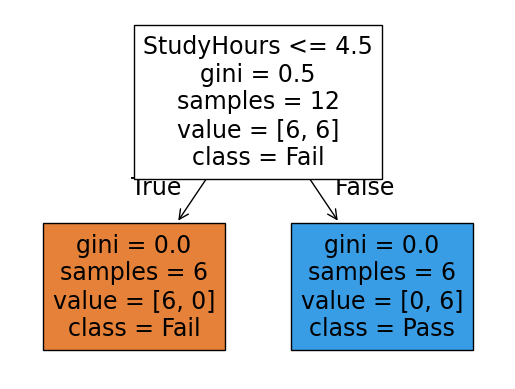

In [ ]:
#  Creation of Decision tree

import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree



data = {
    "StudyHours": [
        1, 2, 2, 3, 3,
        4, 4, 5, 5, 6,
        6, 7, 7, 8, 9
    ],

    "Attendance": [
        50, 55, 60, 65, 68,
        70, 72, 75, 78, 80,
        82, 85, 88, 92, 95
    ],

    "Assignments": [
        2, 3, 3, 4, 4,
        5, 5, 6, 7, 7,
        8, 8, 9, 9, 10
    ],

    "Passed": [
        0, 0, 0, 0, 0,
        0, 0, 1, 1, 1,
        1, 1, 1, 1, 1
    ]
}


df = pd.DataFrame(data)
df

x = df.drop("Passed", axis =1)
y = df["Passed"]
y

model = DecisionTreeClassifier()

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = .20,
    random_state = 42
)

x_train

model.fit(x_train,y_train)

predictions= model.predict(x_test)

print(predictions)

print(y_test)

print(x.columns)

plot_tree(
    model,
    feature_names = x.columns,
    class_names = ["Fail", "Pass"],
    filled = True
)

plt.show()


Recall and F1-Score Metrics - Subjective
********************************************
A machine learning engineer at an environmental-monitoring startup needs a reusable Python

utility that evaluates any batch of forest-region fire-risk predictions the same way the team

does in its manual case-study calculations. Build a function that takes a batch of actual and

predicted fire-risk labels, derives the confusion-matrix counts, and reports precision,

recall, and F1-score — reproducing the exact calculation pattern used for the 25-region case

study, including a manual, zero-guarded F1 helper function alongside the library-based

recall calculation.

Constraints & Requirements:

Use pandas to hold the sample data and sklearn.metrics.confusion_matrix (with labels=[0, 1], negative class listed first) plus sklearn.metrics.recall_score to derive

the confusion-matrix counts and recall, exactly as in the case-study code pattern.

Implement a standalone helper function f1_from_precision_recall(precision, recall) that computes the harmonic mean 2 * precision * recall / (precision + recall), but returns 0

when both precision and recall are 0 (to avoid a division-by-zero when no instance is

predicted positive at all).

Compute precision manually as TP / (TP + FP).

Round all reported metrics to 3 decimal places.

Return the result as a dictionary with keys: tn, fp, fn, tp, precision, recall, f1.

region,actual,predicted
1,1,1
2,1,1
3,1,1
4,1,1
5,1,0
6,0,0
7,0,0
8,0,0
9,0,0
10,0,0
11,0,1
12,0,1

Expected output for that sample: Comparing each row: regions 1–4 are True Positives, region 5 is a False Negative, regions 6–10 are True Negatives, and regions 11–12 are False

Positives. That gives tn=5, fp=2, fn=1, tp=4, so precision = 4/6 ≈ 0.667,

recall = 4/5 = 0.8, and f1 = 2×0.667×0.8/(0.667+0.8) ≈ 0.727.



Recall and F1-Score Metrics - Subjective
Ravel : 5 2 1 4


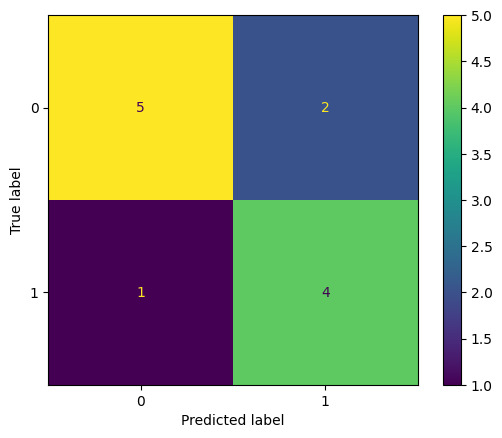

f1 manula:  0.7272727272727272
precision score:  <function precision_score at 0x7b1a73cf9300>
Recall:  0.8
F1:  0.7272727272727273


{'tp': np.int64(4),
 'f1_score': 0.7272727272727273,
 'tn ': np.int64(5),
 'fp ': np.int64(2),
 'fn ': np.int64(1),
 'precision': <function sklearn.metrics._classification.precision_score(y_true, y_pred, *, labels=None, pos_label=1, average='binary', sample_weight=None, zero_division='warn')>,
 'recall': 0.8,
 'f1': 0.7272727272727273}

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix, precision_score, f1_score, recall_score
from io import StringIO
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


print("Recall and F1-Score Metrics - Subjective")


data = """region,actual,predicted
1,1,1
2,1,1
3,1,1
4,1,1
5,1,0
6,0,0
7,0,0
8,0,0
9,0,0
10,0,0
11,0,1
12,0,1"""

df = pd.read_csv(StringIO(data))

def f1_from_precision_recall(precision, recall):

  if (precision == 0) & (recall == 0):

    return 0

  f1_har_mean = 2*precision*recall/(precision + recall)

  return f1_har_mean


def evaluate_model(actual, predicted):

  confusionmetrics = confusion_matrix(actual, predicted, labels=[0,1])

  tn, fp, fn, tp = confusionmetrics.ravel()

  print("Ravel :", tn, fp, fn, tp)

  disp = ConfusionMatrixDisplay(
      confusion_matrix=confusionmetrics,
      display_labels=[0,1])
  # disp.plot(cmap="YlOrRd", colorbar=False)
  disp.plot()
  plt.show()

  precisionscore = precision_score(actual,predicted)

  recalscore = recall_score(actual, predicted)

  f1score = f1_score(actual,predicted)

  f1_manual = f1_from_precision_recall(precisionscore, recalscore)

  print("f1 manula: ", f1_manual)
  print("precision score: ", precision_score)

  print("Recall: ", recalscore)
  print("F1: ", f1score)


  return {
    "tp" : tp,
     "f1_score" : f1score ,
    "tn ": tn,
    "fp ": fp,
    "fn " : fn,
    "precision": precision_score,
    "recall": recalscore,
    "f1" : f1score

  }

evaluate_model(df["actual"],df["predicted"])


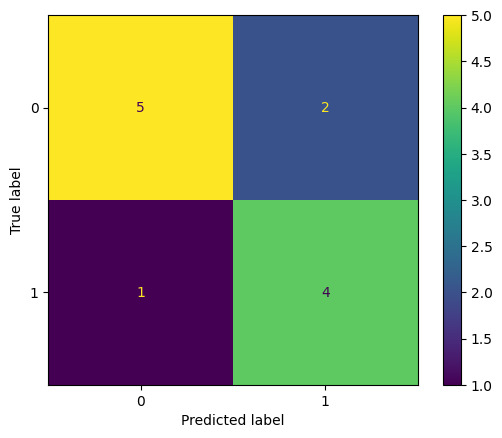

{'tn': 5, 'fp': 2, 'fn': 1, 'tp': 4, 'precision': np.float64(0.667), 'recall': 0.8, 'f1': np.float64(0.727)}


In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, recall_score, ConfusionMatrixDisplay


def f1_from_precision_recall(precision, recall):

    # If both are 0, F1 should be 0
    if precision == 0 and recall == 0:
        return 0

    # Harmonic mean
    return 2 * (precision * recall) / (precision + recall)


def evaluate_model(actual, predicted):

    # Confusion Matrix
    cm = confusion_matrix(
        actual,
        predicted,
        labels= [0,1]
    )

    disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels=[0,1]
    )

    disp.plot()
    plt.show()



    tn, fp, fn, tp = cm.ravel()


    if tp + fp == 0:
        precision = 0
    else:
        precision = tp / (tp + fp)

    # Recall using sklearn
    recall = recall_score(actual, predicted)

    # F1 Score
    f1 = f1_from_precision_recall(precision, recall)

    return {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "f1": round(f1, 3)
    }


if __name__ == "__main__":

    sample = pd.DataFrame({
        "region": range(1, 13),
        "actual": [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        "predicted": [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1],
    })

    print(evaluate_model(
        sample["actual"],
        sample["predicted"]
    ))

max_depth=1: Training Accuracy = 0.812, Test Accuracy = 0.833


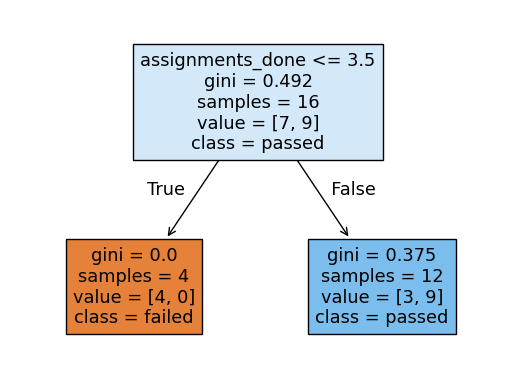

max_depth=2: Training Accuracy = 0.812, Test Accuracy = 1.000


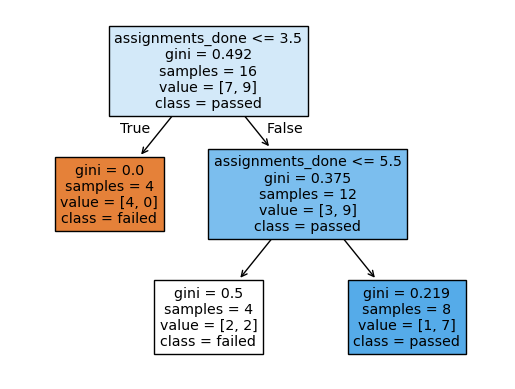

max_depth=3: Training Accuracy = 0.938, Test Accuracy = 0.667


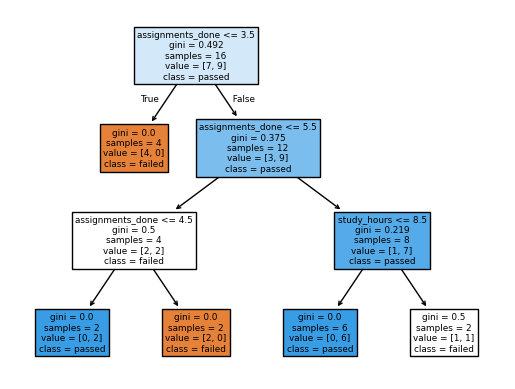

max_depth=None: Training Accuracy = 1.000, Test Accuracy = 0.667


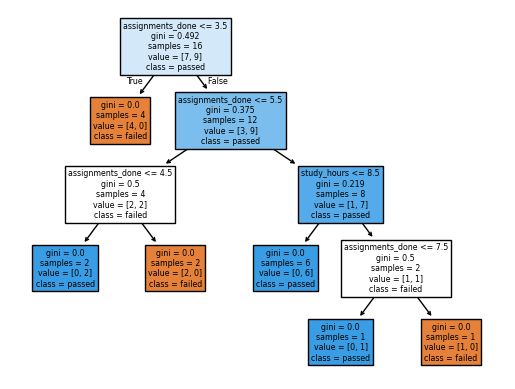

In [ ]:
# A coaching center wants to understand whether a Decision Tree model built to predict whether a student will pass a certification exam is overfitting. You are given records for 22 past students capturing weekly study hours and the number of assignments completed, along with the pass/fail outcome. Train Decision Tree classifiers at several different max_depth values, compare each one's training accuracy against its test accuracy, and identify which depth overfits and which one generalizes best.

# Split the data into training and test sets using test_size=0.25, random_state=42, and stratify on passed so the pass/fail ratio is preserved.
# For each max_depth value in [1, 2, 3, None], create and train a fresh DecisionTreeClassifier(criterion='gini', max_depth=<value>, random_state=42) on the training data.
# For each of the four models, compute and print both the training accuracy and the test accuracy, clearly labeled by depth.
# Based on your own printed results, add a one-line code comment stating (a) which tested depth shows the clearest sign of overfitting (the largest gap between training accuracy and test accuracy) and (b) which tested depth generalizes best (the highest test accuracy among the four).

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt



# -------------------------------------------------
# 1. Create the DataFrame
# -------------------------------------------------

data = pd.DataFrame({

    "study_hours":
        [3, 8, 9, 7, 4, 6, 9, 9, 4, 8, 6, 7, 4, 2, 5, 5, 3, 7, 2, 2, 8, 6],

    "assignments_done":
        [5, 5, 9, 4, 4, 8, 10, 6, 1, 8, 6, 7, 6, 1, 2, 7, 1, 9, 4, 2, 10, 3],

    "passed":
        [0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0]

})


# -------------------------------------------------
# 2. Separate features (X) and target (y)
# -------------------------------------------------

X = data[["study_hours", "assignments_done"]]
y = data["passed"]


# -------------------------------------------------
# 3. Train-Test Split
# -------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


# -------------------------------------------------
# 4. Train Decision Trees with different depths
# -------------------------------------------------

depths = [1, 2, 3, None]

for depth in depths:

    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Accuracy
    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    print(
        f"max_depth={depth}: "
        f"Training Accuracy = {train_accuracy:.3f}, "
        f"Test Accuracy = {test_accuracy:.3f}"
    )

    plt_tree = plot_tree(
        model,
        feature_names = X_train.columns,
        class_names= ["failed", "passed"],
        filled = True

    )
    plt.show()


# max_depth=None shows the clearest overfitting; max_depth=2 generalizes best.

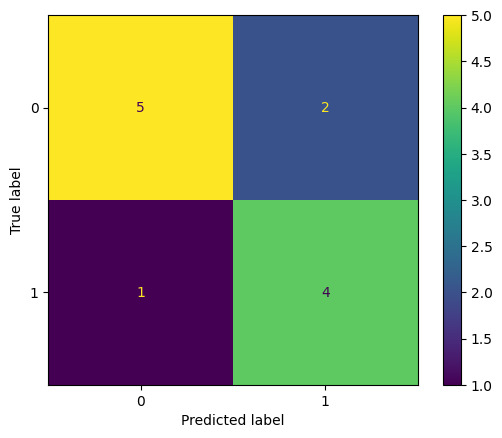

tp: 4 fp: 2 fn: 1 tp:  4
Manual_Precision: 0.667 manual_Recall 0.8 manual_f: 0.727
sk_precision: 0.667 sk_recall: 0.8 sk_f1:  0.727
Result1::: {'tp:': np.int64(4), 'fp:': np.int64(2), 'fn:': np.int64(1), 'sk_precision:': 0.667, 'sk_recall:': 0.8, 'sk_f1:': 0.727}


In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, accuracy_score, recall_score,precision_score
import numpy as np
from io import StringIO
import matplotlib.pyplot as plt



data = """region,actual,predicted
1,1,1
2,1,1
3,1,1
4,1,1
5,1,0
6,0,0
7,0,0
8,0,0
9,0,0
10,0,0
11,0,1
12,0,1"""

df = pd.read_csv(StringIO(data))
df

def evalute_hasan_bodel(actual,predicted):



    cm = confusion_matrix(
        df["actual"],
        df["predicted"],
        labels=[0,1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix = cm,
        display_labels = [0,1]

    )
    disp.plot()
    plt.show()
    tn, fp, fn, tp = cm.ravel()

    manual_precision = tp/(tp+fp)
    manual_recall = tp/(tp + fn)
    manual_f1 = (2*manual_precision*manual_recall)/ (manual_recall + manual_precision)

    print("tp:", tp, "fp:", fp, "fn:", fn, "tp: ", tp)
    print("Manual_Precision:", round(manual_precision,3), "manual_Recall", round(manual_recall,3), "manual_f:", round(manual_f1,3))

    sk_precision = precision_score(df["actual"],df["predicted"])

    sk_recall = recall_score(df["actual"],df["predicted"])

    sk_f1 = f1_score(df["actual"],df["predicted"])

    print("sk_precision:", round(sk_precision,3), "sk_recall:", round(sk_recall,3), "sk_f1: ", round(sk_f1,3))

    return{
        "tp:" : tp,
        "fp:" : fp,
        "fn:" : fn,
        "tp:" : tp,
        "sk_precision:": round(sk_precision,3),
        "sk_recall:" : round(sk_recall,3),
        "sk_f1:" : round(sk_f1,3)
    }

result1 = evalute_hasan_bodel(df["actual"],df["predicted"])
print("Result1:::", result1)


In [ ]:
def classification_score_card(y_true, y_pred, positive_label="late"):

    tp = 0
    tn = 0
    fp = 0
    fn = 0

    # Compare actual and predicted values one by one
    for actual, predicted in zip(y_true, y_pred):

        if actual == positive_label and predicted == positive_label:
            tp += 1

        elif actual != positive_label and predicted != positive_label:
            tn += 1

        elif actual != positive_label and predicted == positive_label:
            fp += 1

        elif actual == positive_label and predicted != positive_label:
            fn += 1

    # Accuracy
    total = tp + tn + fp + fn

    if total == 0:
        accuracy = 0
    else:
        accuracy = (tp + tn) / total

    # Precision
    if tp + fp == 0:
        precision = 0
    else:
        precision = tp / (tp + fp)

    # Recall
    if tp + fn == 0:
        recall = 0
    else:
        recall = tp / (tp + fn)

    # F1 Score
    if precision + recall == 0:
        f1 = 0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    return (
        round(accuracy, 3),
        round(precision, 3),
        round(recall, 3),
        round(f1, 3)
    )




y_true = [
        "late", "late", "late", "late", "late",
        "late", "late", "late",
        "on time", "on time", "on time", "on time", "on time",
        "on time", "on time", "on time", "on time", "on time",
        "on time", "on time"
    ]

y_pred = [
        "late", "late", "late", "late", "late",
        "on time", "on time", "on time",
        "on time", "on time", "on time", "on time", "on time",
        "on time", "on time", "on time", "on time", "on time",
        "late", "late"
    ]

print(classification_score_card(y_true, y_pred))

(0.75, 0.714, 0.625, 0.667)


In [3]:
#  Supervised Learning Pipeline Refinement - Subjective


import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
print("hi")

X_train = [
    [60, 20, 0, 15, 74, 31, 88, 42, 95],
    [55, 25, 1, 72, 19, 84, 36, 91, 27],
    [50, 30, 0, 44, 67, 12, 80, 23, 58],
    [45, 35, 1, 89, 28, 63, 17, 76, 49],
    [5, 115, 1, 33, 92, 47, 61, 14, 85],
    [10, 110, 0, 78, 21, 96, 39, 54, 18],
    [15, 100, 1, 26, 83, 52, 69, 7, 73],
    [20, 90, 0, 64, 11, 75, 30, 98, 41],
]
y_train = [0, 0, 0, 0, 1, 1, 1, 1]
X_test = [
    [58, 22, 0, 53, 46, 37, 29, 62, 70],
    [8, 118, 1, 10, 57, 68, 24, 86, 34],
    [48, 32, 1, 81, 16, 59, 93, 40, 22],
    [18, 95, 0, 35, 79, 8, 55, 66, 90],
]


# Step 1: Declare the scaler, selector, and model steps.
# TODO: Create the documented three-step Pipeline.

# Step 2: Fit with X_train and y_train.
# TODO: Fit the pipeline.

# Step 3: Predict the labels for X_test.
# TODO: Print the prediction list.

hi
